In [1]:
import torch
import numpy as np
import dill

from full_models import *
from curves import *
from interior_models import *
from reparametrization_models import *
from samplers import *
from plotting import *
from losses import *

from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

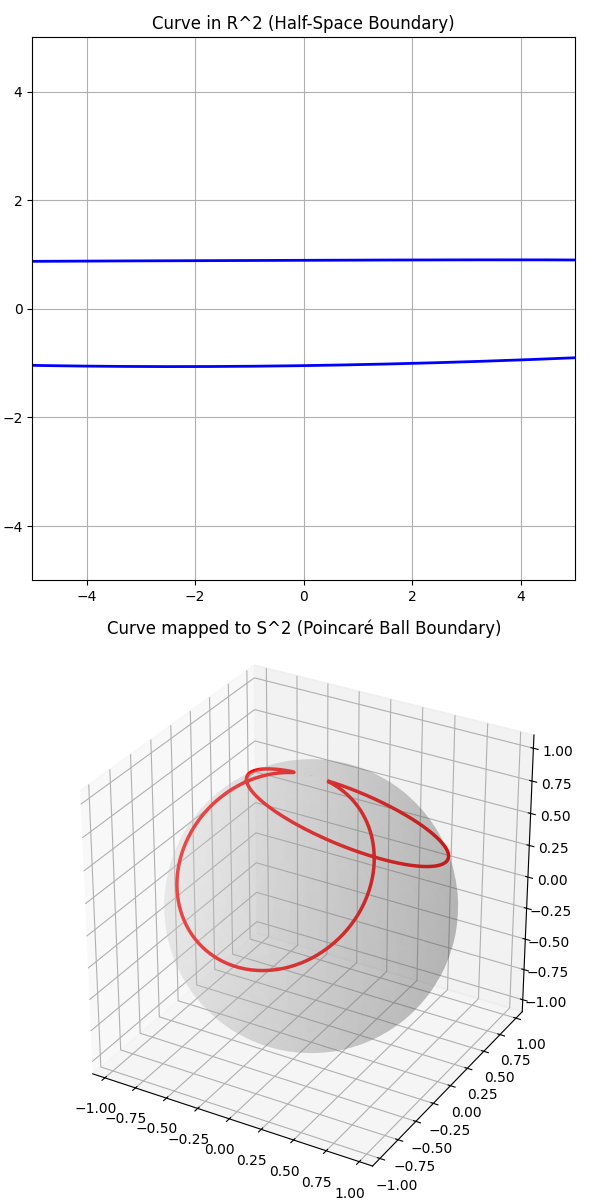

In [2]:
curve = get_ellipse(a=15.0, b=1.0)
curve.perturb(scale = 0.05)
plot_curve_and_projection(curve)

In [3]:
# initial approximation model
interior_model = MLP(output_dim=3)

sampler = MixSampler(
    mix=1,
    bias=0.5,
    # target=(0,0),
    # sigma=0.1
)

reparametrization_model = DiskDiffeomorphismModel()

first_model = MainModel(
    curve=curve,
    interior_model=interior_model,
    sampler=sampler,
    extension_method='stereographic',
    smooth_extension=False,
    # reparametrization_model=reparametrization_model
)

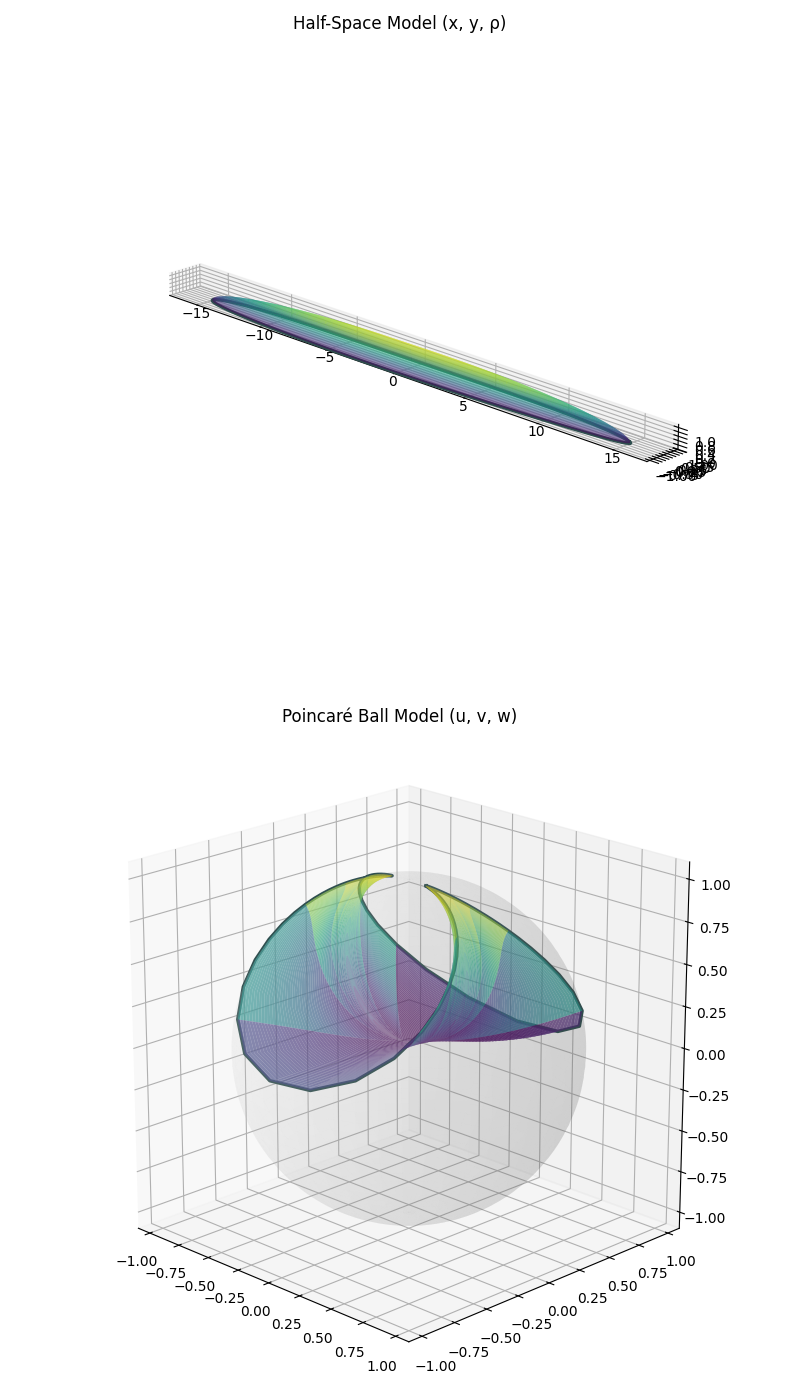

In [4]:
plot_H3_surfaces(
    model_A=first_model,
    model_B=first_model,
    grid_size_A=300,
    grid_size_B=300,
    min_r_A = 0,
    max_r_A = 1,
    min_r_B = 0,
    max_r_B = 1,
    min_theta_A = 0,
    max_theta_A = 2*np.pi,
    min_theta_B = 0,
    max_theta_B = 2*np.pi,
    alpha_A = 0,
    alpha_B = 0.7)

In [5]:
# let's train the first approximation model
_, _, _ = first_model.train_unsupervised_sgd(
    norm_fcn=L2_squared,
    epochs=500,
    dataset_size=2**14,
    batch_size=2**10,
    lr=1e-3,
    lr_min=None
)

Epoch     0/500: Avg Loss = 9.801e-02, LR = 1.000e-03
Epoch    10/500: Avg Loss = 2.524e-02, LR = 9.988e-04
Epoch    20/500: Avg Loss = 1.539e-02, LR = 9.957e-04
Epoch    30/500: Avg Loss = 9.881e-03, LR = 9.906e-04
Epoch    40/500: Avg Loss = 6.256e-03, LR = 9.837e-04
Epoch    50/500: Avg Loss = 4.557e-03, LR = 9.748e-04
Epoch    60/500: Avg Loss = 3.528e-03, LR = 9.641e-04
Epoch    70/500: Avg Loss = 2.448e-03, LR = 9.516e-04
Epoch    80/500: Avg Loss = 2.192e-03, LR = 9.373e-04
Epoch    90/500: Avg Loss = 1.875e-03, LR = 9.213e-04
Epoch   100/500: Avg Loss = 1.626e-03, LR = 9.036e-04
Epoch   110/500: Avg Loss = 1.590e-03, LR = 8.844e-04
Epoch   120/500: Avg Loss = 1.428e-03, LR = 8.637e-04
Epoch   130/500: Avg Loss = 1.334e-03, LR = 8.416e-04
Epoch   140/500: Avg Loss = 1.524e-03, LR = 8.181e-04
Epoch   150/500: Avg Loss = 1.418e-03, LR = 7.934e-04
Epoch   160/500: Avg Loss = 1.233e-03, LR = 7.676e-04
Epoch   170/500: Avg Loss = 1.217e-03, LR = 7.407e-04
Epoch   180/500: Avg Loss = 

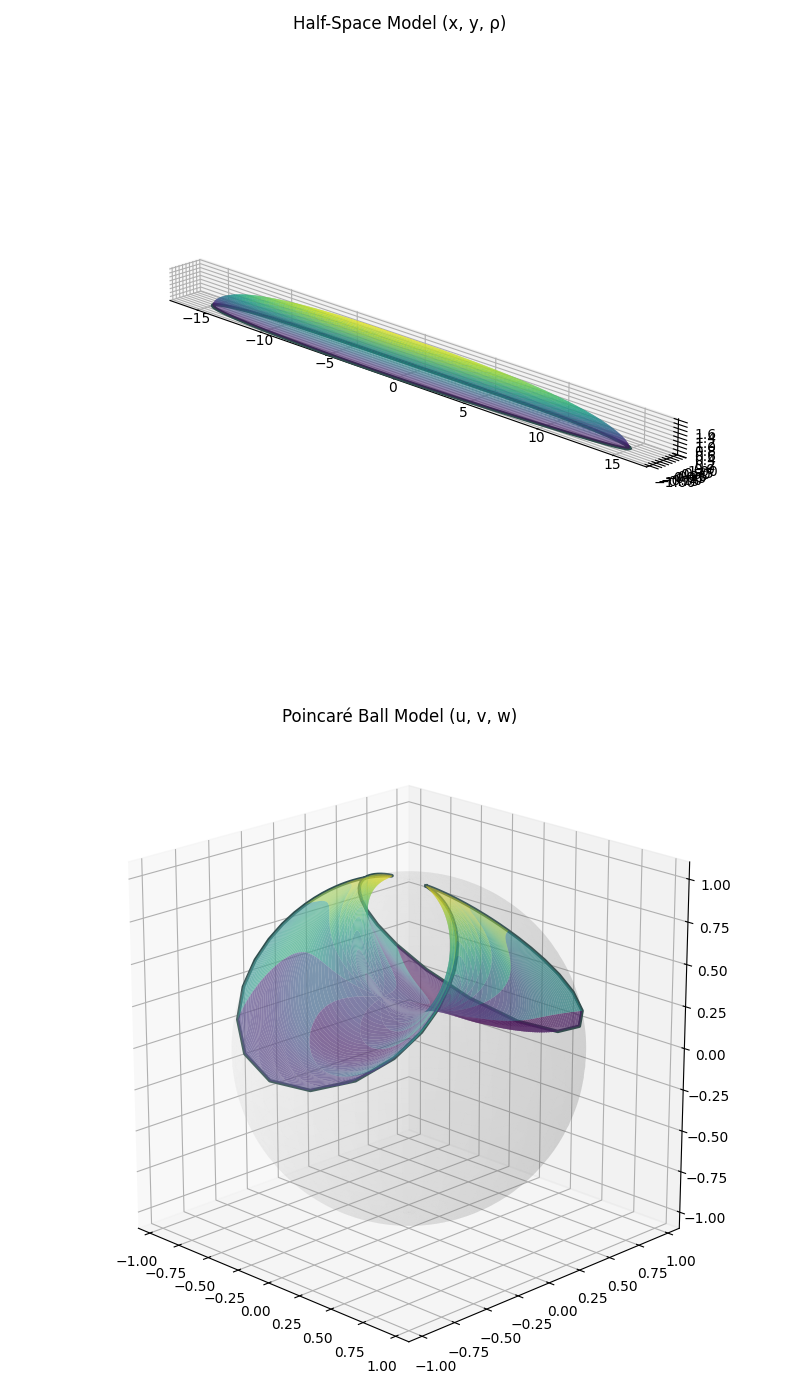

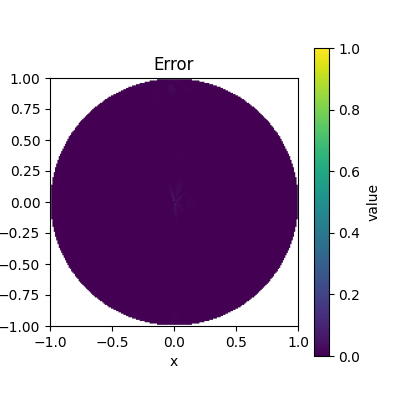

In [6]:
plot_H3_surfaces(
    model_A=first_model,
    model_B=first_model,
    grid_size_A=300,
    grid_size_B=300,
    min_r_A = 0,
    max_r_A = 1,
    min_r_B = 0,
    max_r_B = 1,
    min_theta_A = 0,
    max_theta_A = 2*np.pi,
    min_theta_B = 0,
    max_theta_B = 2*np.pi,
    alpha_A = 0,
    alpha_B = 0.7)

plot_error(
    first_model,
    vmax=1,
    grid_size=200)

In [7]:
# as expected the first approximation exhibits a singularity at the origin
# this is because the fattening method is non-smooth at the origin
# we define now the second, smooth model
interior_model = MLP(output_dim=3)

sampler = MixSampler(
    mix=0.8,
    bias = 0.5,
    target = (0,0), 
    sigma = 0.2
)

# reparametrization_model = DiskDiffeomorphismModel()

second_model = MainModel(
    curve=curve,
    interior_model=interior_model,
    sampler=sampler,
    extension_method='stereographic',
    smooth_extension=True, # this is the crucial change compared to the first model
    treshold=0.01,
    # reparametrization_model=reparametrization_model
)

In [8]:
# if we train the smooth model in the unsupervised way it does not converge
# we need to first train it to resemble the approximated, non-smooth solution we found with the first model
best_supervised, _, _ = second_model.train_supervised_sgd(
    model_supervised=first_model,
    norm_fcn=L2_squared,
    epochs=1000,
    batch_size=2**10,
    lr=1e-3,
    lr_min=None,
    # resample_step=1
)

Epoch     0/1000: Avg Loss = 1.396e+00, LR = 1.000e-03
Epoch    10/1000: Avg Loss = 1.854e-01, LR = 9.997e-04
Epoch    20/1000: Avg Loss = 4.210e-03, LR = 9.989e-04
Epoch    30/1000: Avg Loss = 1.619e-03, LR = 9.977e-04
Epoch    40/1000: Avg Loss = 1.059e-03, LR = 9.959e-04
Epoch    50/1000: Avg Loss = 5.829e-04, LR = 9.937e-04
Epoch    60/1000: Avg Loss = 4.272e-04, LR = 9.909e-04
Epoch    70/1000: Avg Loss = 3.206e-04, LR = 9.877e-04
Epoch    80/1000: Avg Loss = 2.411e-04, LR = 9.841e-04
Epoch    90/1000: Avg Loss = 2.086e-04, LR = 9.799e-04
Epoch   100/1000: Avg Loss = 1.676e-04, LR = 9.753e-04
Epoch   110/1000: Avg Loss = 1.492e-04, LR = 9.702e-04
Epoch   120/1000: Avg Loss = 1.489e-04, LR = 9.647e-04
Epoch   130/1000: Avg Loss = 1.066e-04, LR = 9.587e-04
Epoch   140/1000: Avg Loss = 1.058e-04, LR = 9.522e-04
Epoch   150/1000: Avg Loss = 9.522e-05, LR = 9.453e-04
Epoch   160/1000: Avg Loss = 8.425e-05, LR = 9.380e-04
Epoch   170/1000: Avg Loss = 6.827e-05, LR = 9.303e-04
Epoch   18

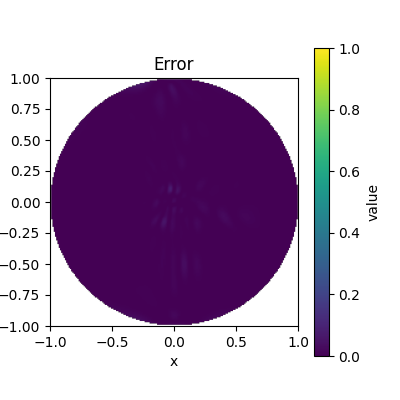

In [9]:
second_model.load_state_dict(best_supervised)

plot_error(
    second_model,
    vmax=1,
    grid_size=200)

In [10]:
# as expected there is a big error at the origin
# however now the unsupervised training loop converges
second_model.load_state_dict(best_supervised)
# second_model.load_state_dict(best_second_model)

best_second_model, _, _ = second_model.train_unsupervised_sgd(
    norm_fcn=L2_squared,
    epochs=2000,
    dataset_size=2**14,
    batch_size=2**10,
    lr=1e-3,
    lr_min=None,
)

Epoch     0/2000: Avg Loss = 8.215e-03, LR = 1.000e-03
Epoch    10/2000: Avg Loss = 5.849e-04, LR = 9.999e-04
Epoch    20/2000: Avg Loss = 7.265e-04, LR = 9.997e-04
Epoch    30/2000: Avg Loss = 5.038e-04, LR = 9.994e-04
Epoch    40/2000: Avg Loss = 3.958e-04, LR = 9.990e-04
Epoch    50/2000: Avg Loss = 2.651e-04, LR = 9.984e-04
Epoch    60/2000: Avg Loss = 2.044e-04, LR = 9.977e-04
Epoch    70/2000: Avg Loss = 2.870e-04, LR = 9.969e-04
Epoch    80/2000: Avg Loss = 1.368e-04, LR = 9.960e-04
Epoch    90/2000: Avg Loss = 2.725e-04, LR = 9.950e-04
Epoch   100/2000: Avg Loss = 1.400e-04, LR = 9.938e-04
Epoch   110/2000: Avg Loss = 2.288e-04, LR = 9.925e-04
Epoch   120/2000: Avg Loss = 1.210e-04, LR = 9.911e-04
Epoch   130/2000: Avg Loss = 1.986e-04, LR = 9.896e-04
Epoch   140/2000: Avg Loss = 1.084e-03, LR = 9.879e-04
Epoch   150/2000: Avg Loss = 1.040e-04, LR = 9.861e-04
Epoch   160/2000: Avg Loss = 1.332e-04, LR = 9.843e-04
Epoch   170/2000: Avg Loss = 1.845e-04, LR = 9.823e-04
Epoch   18

In [11]:
xy = sample_unit_disc(100000)
t = minimal_in_H3_PDE(second_model)(xy)

print('Max pointwise norm of the tension field:', torch.max((t**2).sum(dim=-1)**0.5).detach().item())
print('MSE:', L2_squared(t).detach().item())

Max pointwise norm of the tension field: 0.0625719279050827
MSE: 5.257349130260991e-06


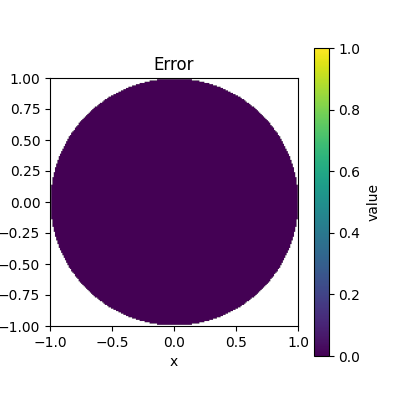

In [12]:
second_model.load_state_dict(best_second_model)

plot_error(
    second_model,
    vmax=1,
    grid_size=200)

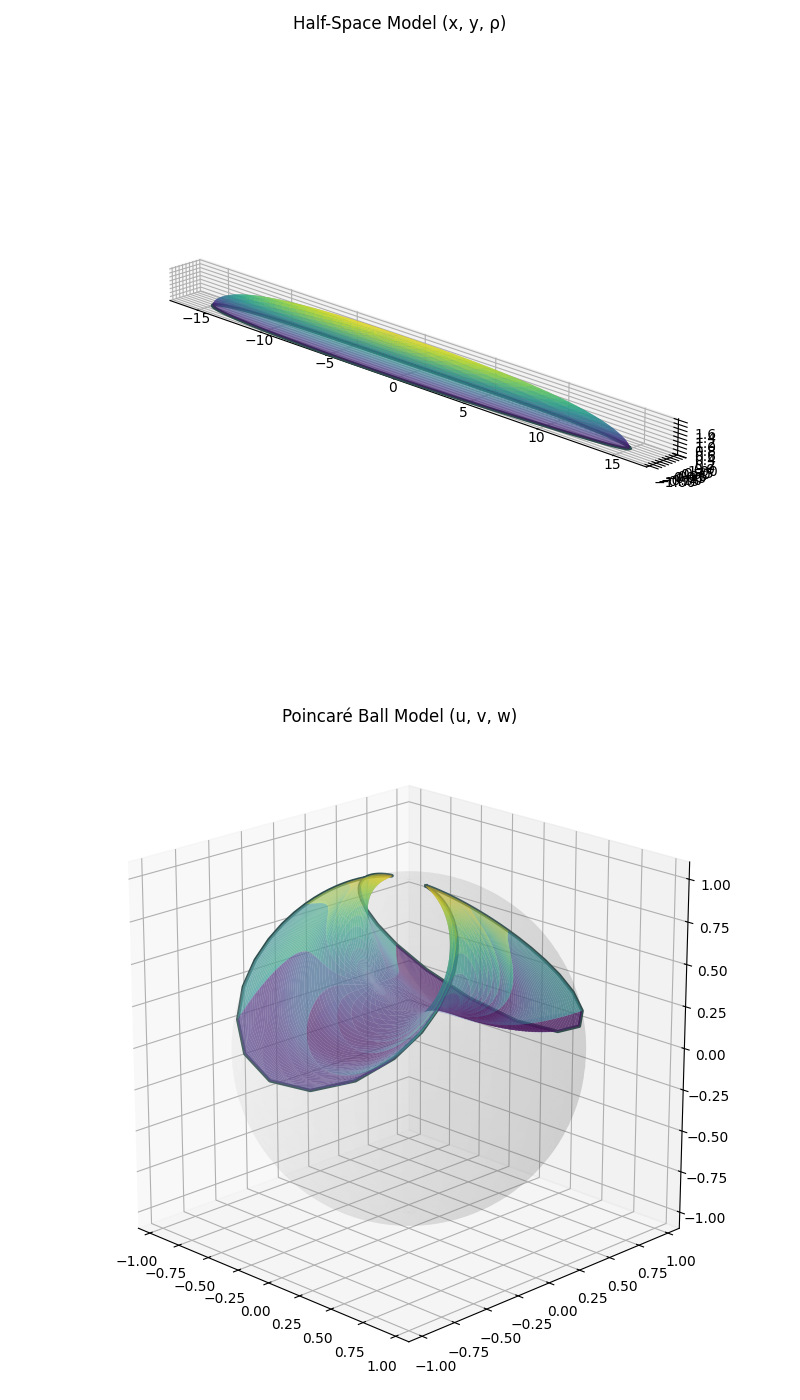

In [15]:
plot_H3_surfaces(
    model_A=first_model,
    model_B=second_model,
    grid_size_A=300,
    grid_size_B=300,
    min_r_A = 0,
    max_r_A = 1,
    min_r_B = 0,
    max_r_B = 1,
    min_theta_A = 0,
    max_theta_A = 2*np.pi,
    min_theta_B = 0,
    max_theta_B = 2*np.pi,
    alpha_A = 0.2,
    alpha_B = 0.7)

In [14]:
# save trained model
trained_models_path = 'pre-trained models/'
# trained_models_path = 'pre-trained models\'

model_name = 'ellipse_1'

with open(trained_models_path + model_name + '.dill', 'wb') as f:
    dill.dump(second_model, f)